In [1]:
import oeio
import oemaestro
import cnotebook
from openeye import oechem

# `oeio` - An modern and extendable I/O framework for the OpenEye Toolkits

The OpenEye Toolkits make molecule I/O in Python pretty easy. For example, reading a molecule from a file:

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x14a6ea310> >
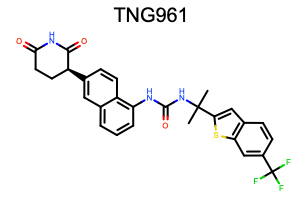

In [2]:
mol = oechem.OEGraphMol()
with oechem.oemolistream("assets/drugs.smi") as ifs:
    oechem.OEReadMolecule(ifs, mol)

mol

Unfortunately, are a couple significant limitations:

1. You cannot add custom readers or writers, such as [oemaestro](https://github.com/scott-arne/oemaestro)
2. It doesn't support modern pipelinining patterns
4. The API can feel a bit complicated to a newcomer
5. Resources are not always freed automatically when objects go out of scope

For these reasons, `oeio` was created. You can see this is a more Pythonic way of reading the first molecule in the file. You'll also notice that `oeio` automatically picks up the `oemaestro` package to read molecules in Maestro file formats:

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x14a1f7d80> >
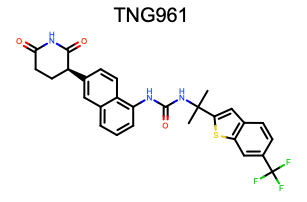

In [4]:
with oeio.read("assets/drugs.mae") as reader:
    mol = next(reader)

mol